In [ ]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No hay GPU. Ve a Entorno de ejecución → Cambiar tipo de entorno → T4 GPU")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
VRAM disponible: 15.6 GB


In [ ]:
!pip install -q diffusers transformers peft datasets accelerate

In [ ]:
print('Actualizando torchao...')
!pip install -q --upgrade torchao

Actualizando torchao...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

output_dir = "/content/drive/MyDrive/lora_model"
print(f"El modelo se guardará en: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
El modelo se guardará en: /content/drive/MyDrive/lora_model


In [ ]:
import os
import random
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from diffusers import StableDiffusionPipeline, DDPMScheduler
from peft import LoraConfig, get_peft_model
from tqdm.notebook import tqdm

device     = "cuda"
model_id   = "runwayml/stable-diffusion-v1-5"
epochs     = 3
lr         = 1e-4
batch_size = 4
gradient_accumulation_steps = 4
max_samples = 5000
image_size  = 512

print("Configuración lista")

Configuración lista


In [ ]:
print("Cargando modelo base (puede tardar ~2 min)...")

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

pipe.vae.requires_grad_(False)
pipe.text_encoder.requires_grad_(False)

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["to_q", "to_v"],
    lora_dropout=0.1,
    bias="none",
)
pipe.unet = get_peft_model(pipe.unet, lora_config)
pipe.unet.print_trainable_parameters()

pipe.unet.to(device)
pipe.vae.to(device)
pipe.text_encoder.to(device)

print("Modelo listo")

Cargando modelo base (puede tardar ~2 min)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


trainable params: 797,184 || all params: 860,318,148 || trainable%: 0.0927
Modelo listo


In [ ]:
class Flickr8kDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, transform, caption_cols):
        self.data         = hf_dataset
        self.tokenizer    = tokenizer
        self.transform    = transform
        self.caption_cols = caption_cols

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample  = self.data[idx]
        image   = sample["image"].convert("RGB")
        image   = self.transform(image)
        col     = random.choice(self.caption_cols)
        caption = sample[col]
        tokens  = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=77,
            return_tensors="pt",
        )
        return {
            "pixel_values": image,
            "input_ids":    tokens.input_ids.squeeze(0),
            "attention_mask": tokens.attention_mask.squeeze(0),
        }

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

print("Descargando dataset Flickr8k...")
raw_dataset = load_dataset("jxie/flickr8k", split="train")
if max_samples:
    raw_dataset = raw_dataset.select(range(min(max_samples, len(raw_dataset))))

sample_keys  = list(raw_dataset[0].keys())
caption_cols = [c for c in sample_keys if c.startswith("caption")]
print(f"Muestras: {len(raw_dataset)} | Captions por imagen: {caption_cols}")

dataset    = Flickr8kDataset(raw_dataset, pipe.tokenizer, transform, caption_cols)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=2, pin_memory=True)
print("Dataset listo")

Descargando dataset Flickr8k...


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Muestras: 5000 | Captions por imagen: ['caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']
Dataset listo


In [ ]:
optimizer = torch.optim.AdamW(pipe.unet.parameters(), lr=lr, weight_decay=1e-2)
scaler    = torch.amp.GradScaler("cuda")

pipe.unet.train()

for epoch in range(epochs):
    print(f"\n── Epoch {epoch+1}/{epochs} ──")
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(dataloader)):
        pixel_values   = batch["pixel_values"].to(device, dtype=torch.float16)
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            latents = pipe.vae.encode(pixel_values).latent_dist.sample()
            latents = latents * pipe.vae.config.scaling_factor
            encoder_hidden_states = pipe.text_encoder(
                input_ids, attention_mask=attention_mask
            ).last_hidden_state

        noise      = torch.randn_like(latents)
        timesteps  = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=device
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        with torch.amp.autocast("cuda"):
            noise_pred = pipe.unet(noisy_latents, timesteps, encoder_hidden_states).sample
            loss = torch.nn.functional.mse_loss(noise_pred.float(), noise.float())

        scaler.scale(loss / gradient_accumulation_steps).backward()

        if (step + 1) % gradient_accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Loss promedio: {total_loss / len(dataloader):.4f}")

print("\nEntrenamiento terminado")


── Epoch 1/3 ──


  0%|          | 0/1250 [00:00<?, ?it/s]

Loss promedio: 0.1705

── Epoch 2/3 ──


  0%|          | 0/1250 [00:00<?, ?it/s]

Loss promedio: 0.1703

── Epoch 3/3 ──


  0%|          | 0/1250 [00:00<?, ?it/s]

Loss promedio: 0.1715

✅ Entrenamiento terminado


In [ ]:
os.makedirs(output_dir, exist_ok=True)
pipe.unet.save_pretrained(output_dir)
print(f"Modelo guardado en: {output_dir}")

Modelo guardado en: /content/drive/MyDrive/lora_model


  0%|          | 0/30 [00:00<?, ?it/s]

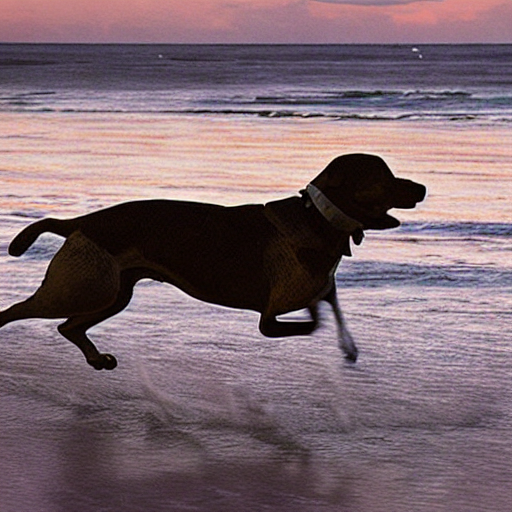

Prompt: a dog running on a beach at sunset, photorealistic


In [ ]:
from IPython.display import display

pipe.to(device)
pipe.unet.eval()

prompt = "a dog running on a beach at sunset, photorealistic"

with torch.no_grad():
    image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

display(image)
image.save("/content/prueba.png")
print(f"Prompt: {prompt}")